# Additional model checks

Exploratory notebook for checking model behaviour outside the main paper pipeline.

## §1: In-sample KL divergence vs η

We calibrate the spatial bias field to a single decade, initialise the model at the start of
that decade using the MAP state field, evolve it forward to the end, and compute the mean
KL divergence
$$\bar{D}_{\mathrm{KL}} = \frac{1}{T_{\mathrm{win}}} \sum_{t=1}^{T_{\mathrm{win}}} \frac{1}{N} \sum_{i=1}^{N} \sum_k \hat{x}_{ik}^{\mathrm{MAP}}(t_0+t)\log\frac{\hat{x}_{ik}^{\mathrm{MAP}}(t_0+t)}{\hat{x}_{ik}^{\mathrm{pred}}(t_0+t)}$$
as a function of the bias field length scale η.  This is an **in-sample** check: the same
decade is used for both fitting and evaluation.

**Prerequisites:** W and L generators (built in the cell below — may take ~2 min).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent / 'src'))

import glob
import importlib

import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from scipy.spatial import distance_matrix
from scipy.optimize import minimize

import spatial_model as sm
import model_inference as mif

importlib.reload(sm)
importlib.reload(mif)

<module 'model_inference' from 'C:\\Users\\james\\Dropbox\\RESEARCH\\APEX_2024\\REPO\\code\\src\\model_inference.py'>

In [2]:
repo_root   = Path().resolve().parents[1]
voronoi_dir = repo_root / 'data' / 'voronois'
p_field_dir = repo_root / 'data' / 'probability_fields'
fig_dir     = repo_root / 'figures'

n_demes    = 4000
start_year = 1950
end_year   = 2000
J          = 0.1

In [3]:
gdf_voronoi = gpd.read_file(voronoi_dir / f'Voronoi_{n_demes}_raw_kmeans_demes.gpkg')
DX   = np.column_stack([gdf_voronoi.x.values, gdf_voronoi.y.values])
dmat = distance_matrix(DX, DX) / 1e3
pops = gdf_voronoi['pop'].values
N    = len(pops)
print(f'N = {N} cells')

d0, gamma0, gamma1, alpha_mig, lambda_bar = 48.91, 5.57, -0.35, 0.60, 0.063
R = 100

c = sm.get_c(pops, dmat, d0, gamma0, gamma1, alpha_mig, lambda_bar)

print('Building W ...')
W = sm.migration_generator(dmat, pops, d0, gamma0, gamma1, alpha_mig, c)
print('Building L ...')
L = sm.diffusion_generator(dmat, pops, R)
print('Done.')

N = 4000 cells
Building W ...
Building L ...
Done.


In [4]:
v4_files = sorted(glob.glob(str(p_field_dir / 'v_4_*.npy')))

variables = {}
for f in v4_files:
    P     = np.load(f)
    K     = P.shape[2]
    parts = Path(f).stem.split('_')
    key   = '_'.join(parts[2:2 + K])
    variables[key] = {'P': P, 'K': K, 'variants': parts[2:2 + K]}

var_order = [
    ('crawfish_crayfish_crawdad', 'crawfish / crayfish / crawdad'),
    ('roly_bug',                  'roly / bug'),
    ('soda_pop_coke',             'soda / pop / coke'),
    ('sunshower_devil',           'sunshower / devil'),
    ('tennis_sneakers',           'tennis / sneakers'),
    ('you-guys_you-all',          'you-guys / you-all'),
]

for key, v in variables.items():
    print(f'{key:40s}  shape {v["P"].shape}')

crawfish_crayfish_crawdad                 shape (4000, 51, 3)
roly_bug                                  shape (4000, 51, 2)
soda_pop_coke                             shape (4000, 51, 3)
sunshower_devil                           shape (4000, 51, 2)
tennis_sneakers                           shape (4000, 51, 2)
you-guys_you-all                          shape (4000, 51, 2)


## §1: In-sample calibration — configure here

In [5]:
# Decade to calibrate on (index space: 0 = 1950, 10 = 1960, ...)
t0 = 10   # 1970
t1 = 20   # 1980

# Geometric sequence of η values (km)
etas = np.round(200 * 1.5 ** np.arange(9)).astype(int)   # ~200 to ~5100 km
etas = etas[etas <= 4000]                                 # trim to 4000 km
print(f'Decade: {start_year + t0}–{start_year + t1}')
print(f'η values (km): {etas}')

REG  = 1e-4
Rmin = 0.99

Decade: 1960–1970
η values (km): [ 200  300  450  675 1012 1519 2278 3417]


Variable: roly_bug  K=2
Decade: 1960–1970

  η=  200 km  Q=178  β=0.210  mean KL=0.00122
  η=  300 km  Q= 87  β=0.214  mean KL=0.00186
  η=  450 km  Q= 44  β=0.213  mean KL=0.00237
  η=  675 km  Q= 23  β=0.215  mean KL=0.00271
  η= 1012 km  Q= 13  β=0.213  mean KL=0.00288
  η= 1519 km  Q=  8  β=0.214  mean KL=0.00330
  η= 2278 km  Q=  5  β=0.213  mean KL=0.00341
  η= 3417 km  Q=  4  β=0.211  mean KL=0.00352


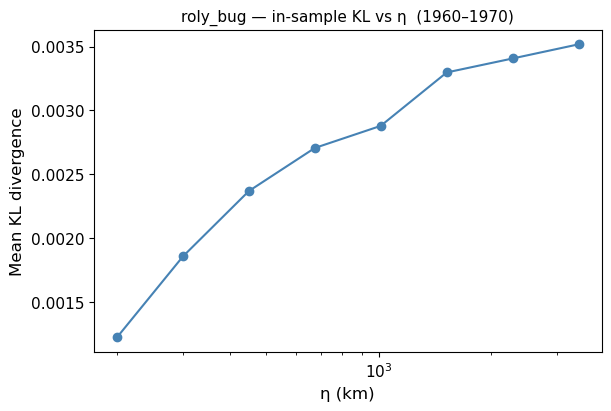

In [6]:
# Quick single-variable check (roly_bug) — runs before the full grid

T_win = t1 - t0

key_single = 'roly_bug'
P_s = variables[key_single]['P']
K_s = variables[key_single]['K']
print(f'Variable: {key_single}  K={K_s}')
print(f'Decade: {start_year + t0}–{start_year + t1}\n')

single_results = {}

for eta in etas:
    A_eta, Q_eta, _ = mif.simple_basis(eta, dmat, Rmin)

    obj = sm.make_spatial_bias_objective(P_s, W, L, A_eta, J, t0, t1, reg=REG)
    res = minimize(obj, np.zeros(1 + Q_eta * K_s))   # default BFGS
    beta_fit = res.x[0]
    s_fit    = A_eta @ res.x[1:].reshape(Q_eta, K_s)

    mod  = sm.model(W, L, J, s_fit, beta_fit, P_s[:, t0, :].copy())
    xsol = mod.solve(np.arange(T_win + 1))

    X_pred  = xsol.transpose(1, 0, 2)[:, 1:, :]
    X_true  = P_s[:, t0 + 1 : t1 + 1, :]
    kld_ts  = sm.kld_time_series(X_true, X_pred)
    mean_kl = kld_ts.mean()

    single_results[eta] = {'beta': beta_fit, 'mean_kl': mean_kl, 'kld_ts': kld_ts, 'Q': Q_eta}
    print(f'  η={eta:5d} km  Q={Q_eta:3d}  β={beta_fit:.3f}  mean KL={mean_kl:.5f}')

# Quick plot
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax.plot(etas, [single_results[e]['mean_kl'] for e in etas], 'o-', color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('η (km)', fontsize=12)
ax.set_ylabel('Mean KL divergence', fontsize=12)
ax.set_title(f'{key_single} — in-sample KL vs η  ({start_year + t0}–{start_year + t1})', fontsize=11)
ax.tick_params(labelsize=11)
plt.show()

In [7]:
# Compute cell — fit bias and evaluate in-sample KL for each variable and η
# May take 10–20 min for all 6 variables × len(etas) optimisations

T_win = t1 - t0

calib_results = {}   # calib_results[key][eta] = dict

for idx, (key, label) in enumerate(var_order):
    P_v = variables[key]['P']
    K_v = variables[key]['K']
    print(f'\n({chr(97 + idx)}) {label}  K={K_v}')
    calib_results[key] = {}

    for eta in etas:
        A_eta, Q_eta, _ = mif.simple_basis(eta, dmat, Rmin)

        # Fit (β, ψ) on this decade
        obj = sm.make_spatial_bias_objective(P_v, W, L, A_eta, J, t0, t1, reg=REG)
        res = minimize(obj, np.zeros(1 + Q_eta * K_v))   # default BFGS
        beta_fit = res.x[0]
        s_fit    = A_eta @ res.x[1:].reshape(Q_eta, K_v)

        # Run model forward from start of decade
        mod  = sm.model(W, L, J, s_fit, beta_fit, P_v[:, t0, :].copy())
        xsol = mod.solve(np.arange(T_win + 1))   # (T_win+1, N, K)

        # KL at each year, skipping t=0 (initial condition)
        X_pred  = xsol.transpose(1, 0, 2)[:, 1:, :]     # (N, T_win, K)
        X_true  = P_v[:, t0 + 1 : t1 + 1, :]            # (N, T_win, K)
        kld_ts  = sm.kld_time_series(X_true, X_pred)     # (T_win,)
        mean_kl = kld_ts.mean()

        calib_results[key][eta] = {
            'beta':     beta_fit,
            'mean_kl':  mean_kl,
            'kld_ts':   kld_ts,
            'Q':        Q_eta,
        }
        print(f'  η={eta:5d} km  Q={Q_eta:3d}  β={beta_fit:.3f}  mean KL={mean_kl:.5f}')

print('\nAll done.')


(a) crawfish / crayfish / crawdad  K=3
  η=  200 km  Q=178  β=0.283  mean KL=0.00566
  η=  300 km  Q= 87  β=0.289  mean KL=0.00669
  η=  450 km  Q= 44  β=0.292  mean KL=0.00768
  η=  675 km  Q= 23  β=0.285  mean KL=0.00830
  η= 1012 km  Q= 13  β=0.281  mean KL=0.00891
  η= 1519 km  Q=  8  β=0.273  mean KL=0.00971
  η= 2278 km  Q=  5  β=0.266  mean KL=0.00971
  η= 3417 km  Q=  4  β=0.263  mean KL=0.00980

(b) roly / bug  K=2
  η=  200 km  Q=178  β=0.210  mean KL=0.00122
  η=  300 km  Q= 87  β=0.214  mean KL=0.00186
  η=  450 km  Q= 44  β=0.213  mean KL=0.00237
  η=  675 km  Q= 23  β=0.215  mean KL=0.00271
  η= 1012 km  Q= 13  β=0.213  mean KL=0.00288
  η= 1519 km  Q=  8  β=0.214  mean KL=0.00330
  η= 2278 km  Q=  5  β=0.213  mean KL=0.00341
  η= 3417 km  Q=  4  β=0.211  mean KL=0.00352

(c) soda / pop / coke  K=3
  η=  200 km  Q=178  β=0.228  mean KL=0.00726
  η=  300 km  Q= 87  β=0.232  mean KL=0.00854
  η=  450 km  Q= 44  β=0.231  mean KL=0.00976
  η=  675 km  Q= 23  β=0.225  mean KL

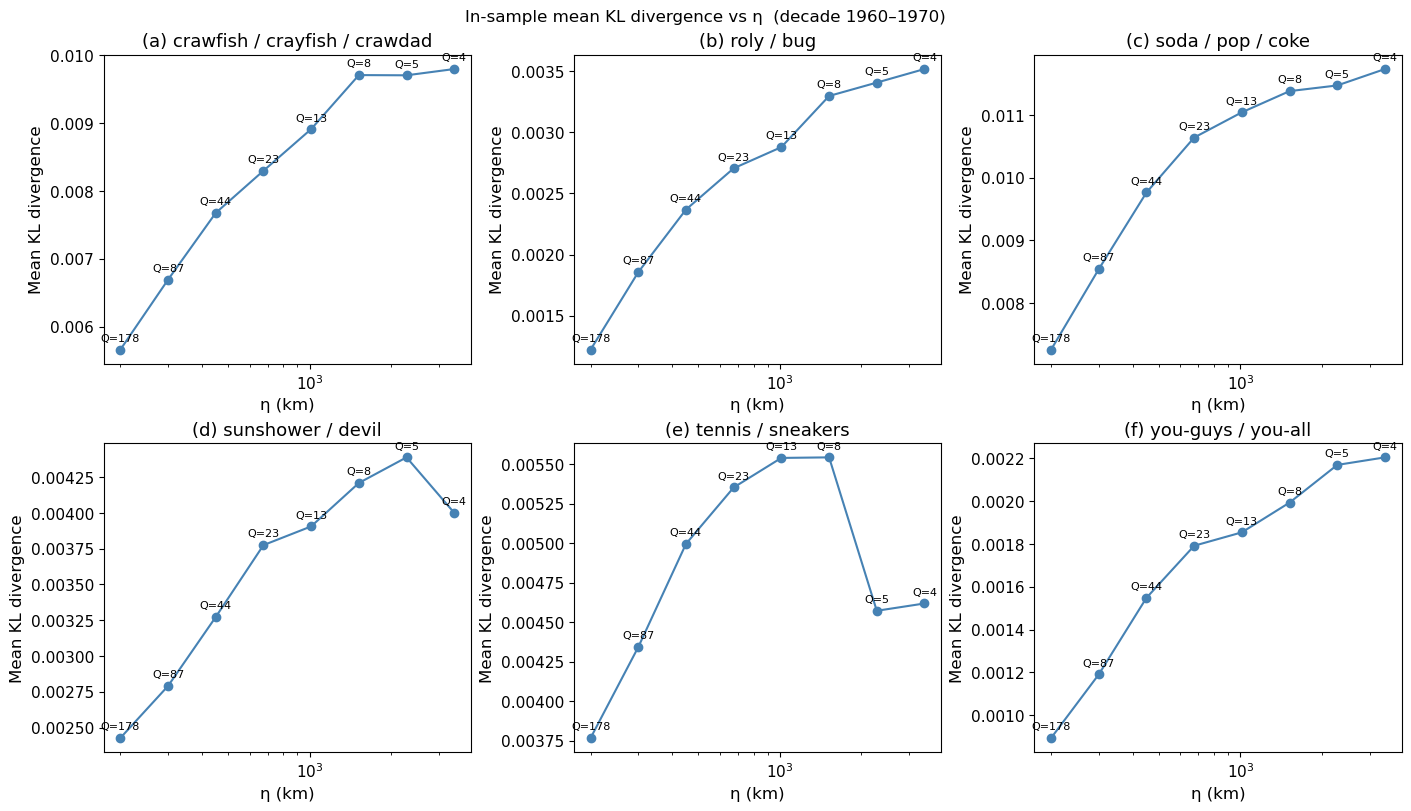

In [8]:
# Plot — rerun freely without recomputing

decade_str = f'{start_year + t0}\u2013{start_year + t1}'

fig, axs = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for idx, (key, label) in enumerate(var_order):
    ax  = axs[idx // 3, idx % 3]
    res = calib_results[key]

    mean_kls = [res[eta]['mean_kl'] for eta in etas]
    Qs       = [res[eta]['Q']       for eta in etas]

    ax.plot(etas, mean_kls, 'o-', color='steelblue')
    ax.set_xscale('log')
    ax.set_title(f'({chr(97 + idx)}) {label}', fontsize=13)
    ax.set_xlabel('\u03b7 (km)', fontsize=12)
    ax.set_ylabel('Mean KL divergence', fontsize=12)
    ax.tick_params(labelsize=11)

    for eta, mk, Q in zip(etas, mean_kls, Qs):
        ax.annotate(f'Q={Q}', (eta, mk), textcoords='offset points',
                    xytext=(0, 6), ha='center', fontsize=8)

plt.suptitle(f'In-sample mean KL divergence vs \u03b7  (decade {decade_str})', fontsize=12)
plt.savefig(fig_dir / f'calib_kl_vs_eta_{start_year + t0}_{start_year + t1}.png',
            dpi=300, bbox_inches='tight')
plt.show()

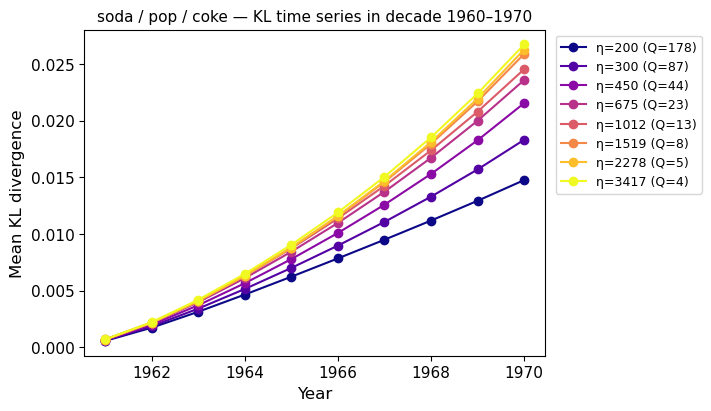

In [9]:
# Optional: KL time series within the decade for a single variable
# Shows how in-sample error grows across the decade for each η

key_ts   = 'soda_pop_coke'
label_ts = dict(var_order)[key_ts]
years_ts = np.arange(start_year + t0 + 1, start_year + t1 + 1)

cmap_eta = plt.cm.plasma
eta_colors = {eta: cmap_eta(i / (len(etas) - 1)) for i, eta in enumerate(etas)}

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

for eta in etas:
    kld_ts = calib_results[key_ts][eta]['kld_ts']
    Q      = calib_results[key_ts][eta]['Q']
    ax.plot(years_ts, kld_ts, 'o-', color=eta_colors[eta], label=f'\u03b7={eta} (Q={Q})')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean KL divergence', fontsize=12)
ax.set_title(f'{label_ts} — KL time series in decade {decade_str}', fontsize=11)
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(labelsize=11)
plt.show()